In [34]:
import pandas as pd
import numbers as np 
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

from sklearn.preprocessing import PowerTransformer

In [36]:
df = pd.read_csv('concrete_data.csv')

In [37]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [38]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [39]:
X = df.drop(columns=['Strength'])
y = df.iloc[:,-1]

In [40]:
X_train , X_test , y_train, y_test = train_test_split(X,y , test_size=0.2,random_state=42)

In [41]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

r2_score(y_test,y_pred)

0.627553179231485

In [42]:
cross_val_score(lr, X, y, scoring='r2')

array([0.33015205, 0.41207076, 0.45175533, 0.60725028, 0.50374183])

In [43]:
# scaling is automatically done when applying and transformation so don't need to do it explicitly




# from sklearn.preprocessing import MinMaxScaler
# ms = MinMaxScaler()
# ms.fit(X_train)
# X_train_transformed = pd.DataFrame(ms.transform(X_train))
# X_test_transformed = pd.DataFrame(ms.transform(X_test))

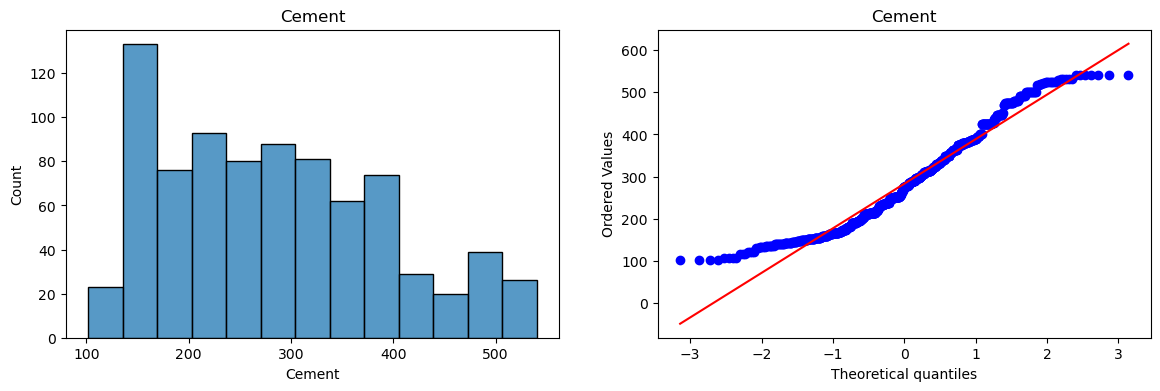

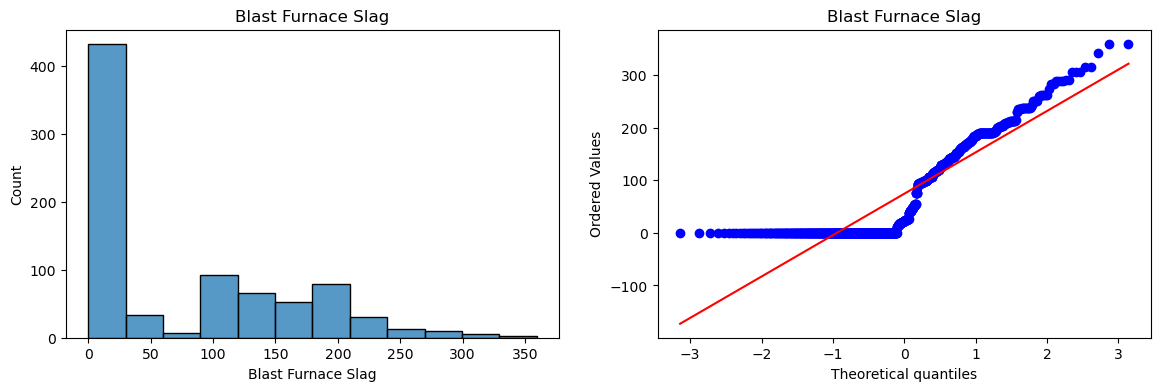

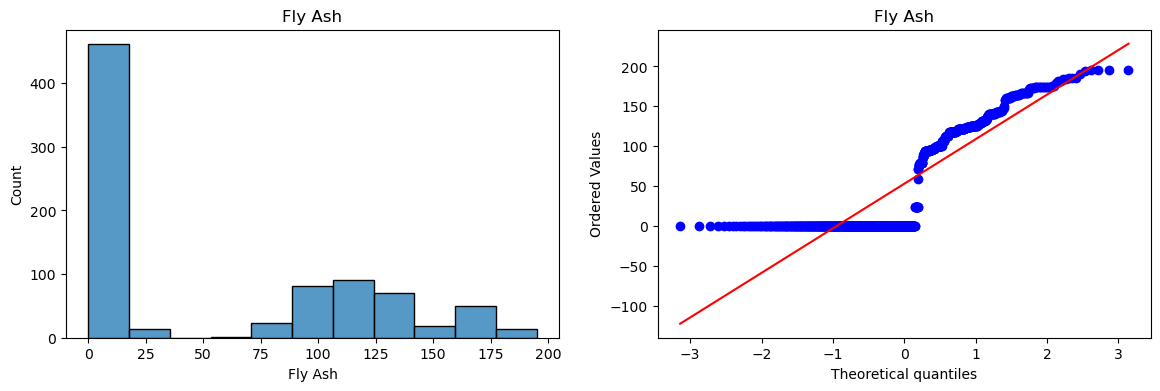

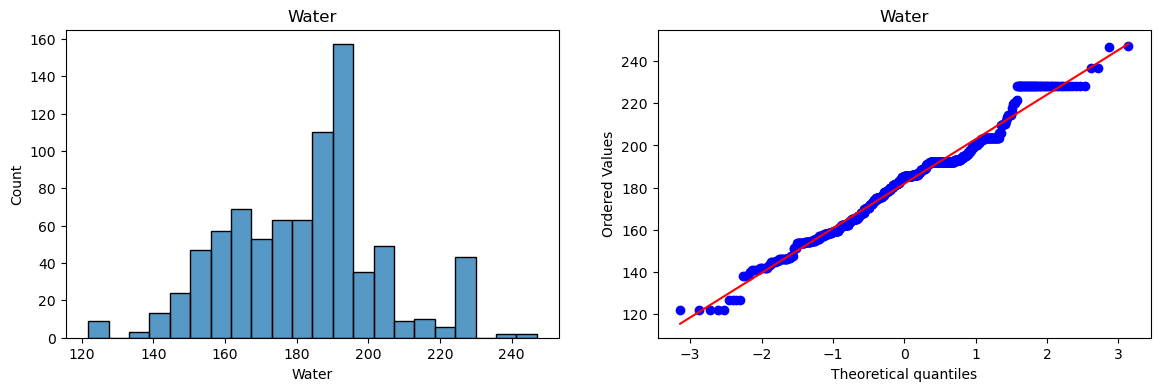

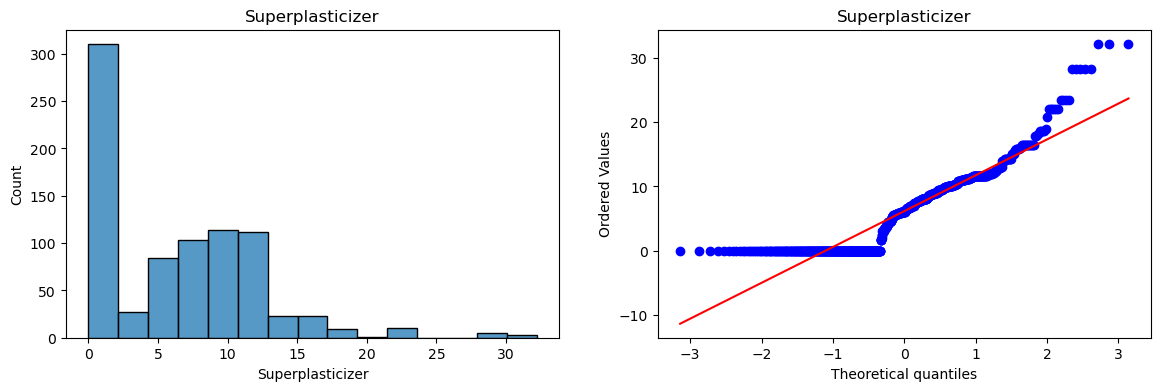

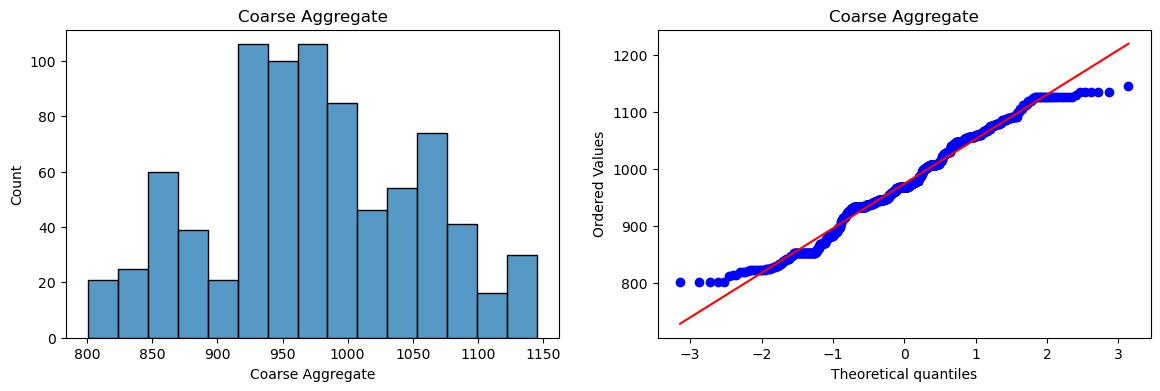

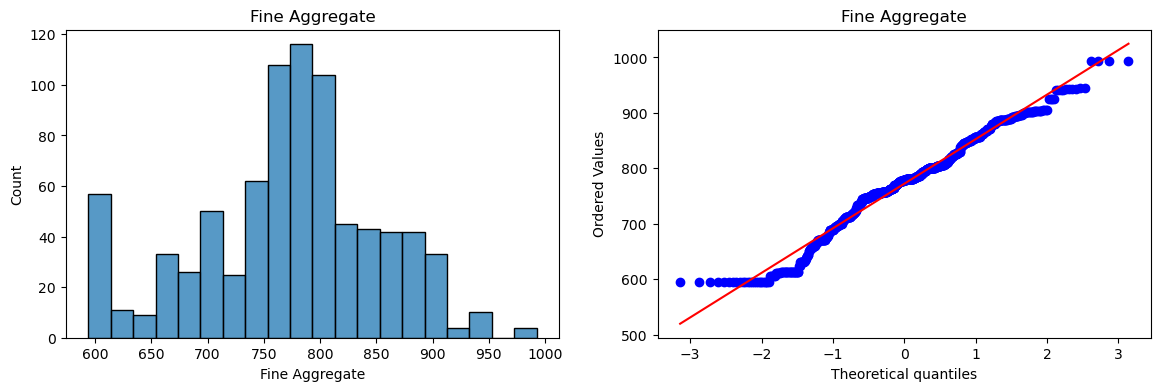

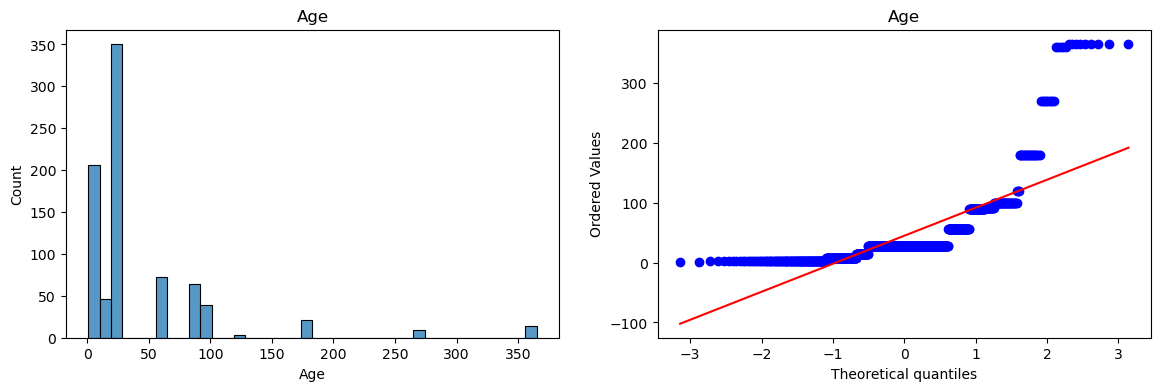

In [44]:
for col in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(1,2,1)
    sns.histplot(X_train[col])
    plt.title(col)


    plt.subplot(1,2,2)
    stats.probplot(X_train[col],dist="norm",plot=plt)
    plt.title(col)

    plt.show()

In [45]:
pt = PowerTransformer(method='box-cox')

X_train_transformed = pt.fit_transform(X_train+0.000001)
X_test_transformed = pt.fit_transform(X_test+0.000001)

pd.DataFrame({'cols':X_train.columns,'box_cox_lambda':pt.lambdas_})

,cols,box_cox_lambda
0,Cement,0.215602
1,Blast Furnace Slag,0.025996
2,Fly Ash,-0.006544
3,Water,0.959062
4,Superplasticizer,0.103365
5,Coarse Aggregate,1.192492
6,Fine Aggregate,1.973781
7,Age,-0.014692


In [46]:
lr = LinearRegression()

lr.fit(X_train_transformed, y_train)

y_pred = lr.predict(X_test_transformed)

r2_score(y_test,y_pred)

0.8055321002541033